In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Rencana_Studi/Semester_VIII/Deep_Learning/UTS/kasus_satu/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Rencana_Studi/Semester_VIII/Deep_Learning/UTS/kasus_satu/test.csv')

# **Preprocessing Data Training**

In [ ]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
train = train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Survived' ]]

In [ ]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,3,male,22.0,1,0,7.2500,NaN,S,0
1,1,female,38.0,1,0,71.2833,C85,C,1
2,3,female,26.0,0,0,7.9250,NaN,S,1
3,1,female,35.0,1,0,53.1000,C123,S,1
4,3,male,35.0,0,0,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,NaN,S,0
887,1,female,19.0,0,0,30.0000,B42,S,1
888,3,female,NaN,1,2,23.4500,NaN,S,0
889,1,male,26.0,0,0,30.0000,C148,C,1


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Cabin     204 non-null    object 
 7   Embarked  889 non-null    object 
 8   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [ ]:
train['Cabin'].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [ ]:
train['Cabin'] = train['Cabin'].fillna('U').apply(lambda x: x[0])

/tmp/ipykernel_8512/725298484.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Cabin'] = train['Cabin'].fillna('U').apply(lambda x: x[0])


In [ ]:
train.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,2
Survived,0


In [ ]:
train['Cabin'].value_counts()


,count
Cabin,
U,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [ ]:
train.dropna(subset=['Embarked'], inplace=True)

/tmp/ipykernel_8512/3576571723.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.dropna(subset=['Embarked'], inplace=True)


In [ ]:
train['Age'].fillna(train['Age'].median(), inplace=True)

/tmp/ipykernel_8512/486169235.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
/tmp/ipykernel_8512/486169235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Age'].fillna(train['Age'].median(), inplace=True)


In [ ]:
train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0
Survived,0


In [ ]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,3,male,22.0,1,0,7.2500,U,S,0
1,1,female,38.0,1,0,71.2833,C,C,1
2,3,female,26.0,0,0,7.9250,U,S,1
3,1,female,35.0,1,0,53.1000,C,S,1
4,3,male,35.0,0,0,8.0500,U,S,0
...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,U,S,0
887,1,female,19.0,0,0,30.0000,B,S,1
888,3,female,28.0,1,2,23.4500,U,S,0
889,1,male,26.0,0,0,30.0000,C,C,1


In [ ]:
train['Cabin'].value_counts()

,count
Cabin,
U,687
C,59
B,45
D,33
E,32
A,15
F,13
G,4
T,1


In [ ]:
sex_mapping = {'male': 0, 'female': 1}
train['Sex'] = train['Sex'].map(sex_mapping)

embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
train['Embarked'] = train['Embarked'].map(embarked_mapping)

cabin_mapping = {'U': 0, 'C': 1, 'B': 2, 'D':3, 'E':4, 'A':5, 'F':6, 'G':7, 'T':8}
train['Cabin'] = train['Cabin'].map(cabin_mapping)

/tmp/ipykernel_8512/3599556539.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Sex'] = train['Sex'].map(sex_mapping)
/tmp/ipykernel_8512/3599556539.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Embarked'] = train['Embarked'].map(embarked_mapping)
/tmp/ipykernel_8512/3599556539.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

In [ ]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,3,0,22.0,1,0,7.2500,0,0,0
1,1,1,38.0,1,0,71.2833,1,1,1
2,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,1
4,3,0,35.0,0,0,8.0500,0,0,0
...,...,...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,0,0,0
887,1,1,19.0,0,0,30.0000,2,0,1
888,3,1,28.0,1,2,23.4500,0,0,0
889,1,0,26.0,0,0,30.0000,1,1,1


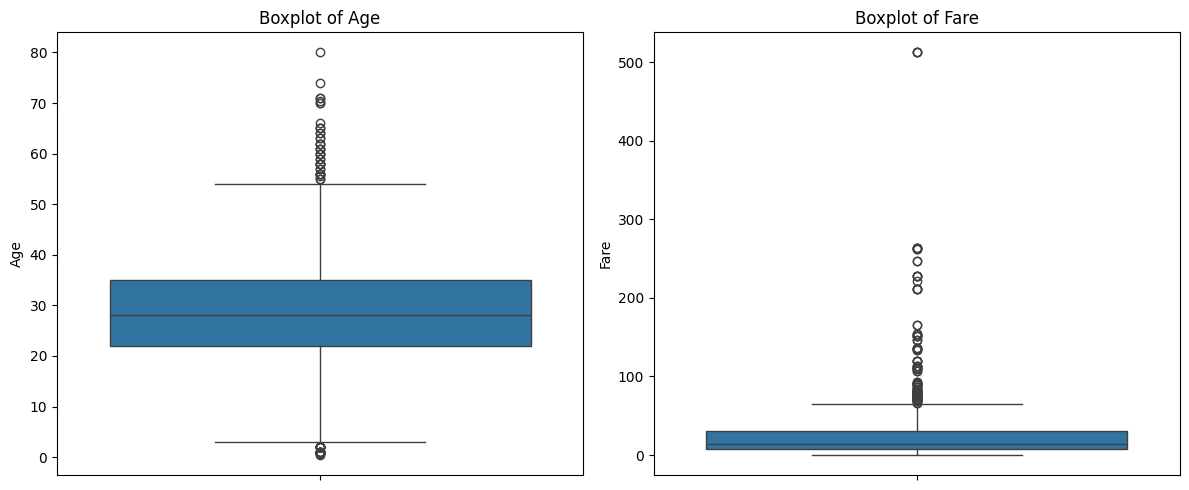

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=train['Age'])
plt.title('Boxplot of Age')

plt.subplot(1, 2, 2)
sns.boxplot(y=train['Fare'])
plt.title('Boxplot of Fare')

plt.tight_layout()
plt.show()

In [ ]:
# Function to replace outliers with IQR bounds
def replace_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers
    df.loc[df[column] < lower_bound, column] = lower_bound
    df.loc[df[column] > upper_bound, column] = upper_bound
    return df

# Apply to 'Age' column
train = replace_outliers_iqr(train, 'Age')

# Apply to 'Fare' column
train = replace_outliers_iqr(train, 'Fare')

print("Outliers in 'Age' and 'Fare' columns have been replaced.")

Outliers in 'Age' and 'Fare' columns have been replaced.


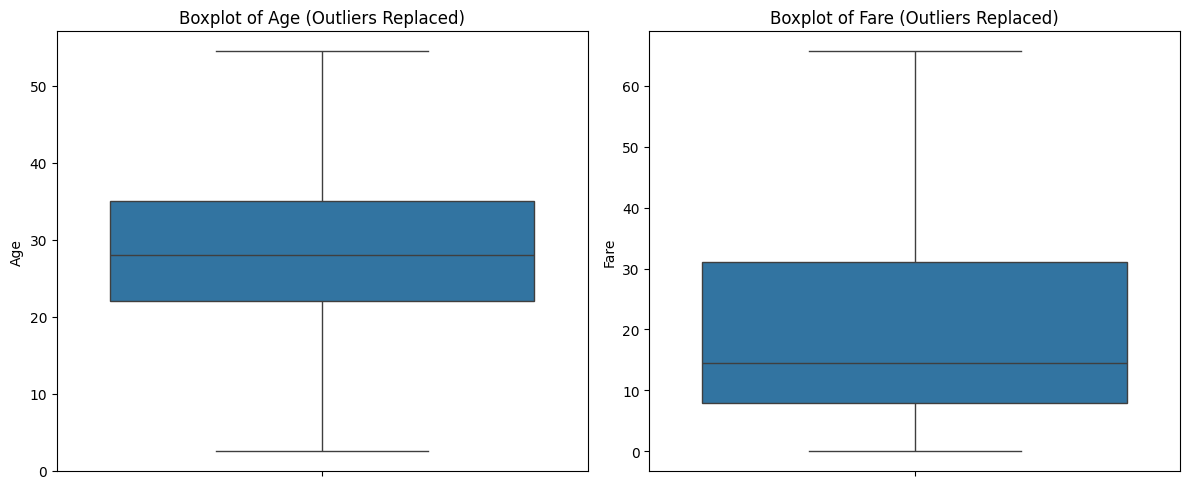

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=train['Age'])
plt.title('Boxplot of Age (Outliers Replaced)')

plt.subplot(1, 2, 2)
sns.boxplot(y=train['Fare'])
plt.title('Boxplot of Fare (Outliers Replaced)')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[['Age', 'Fare']] = scaler.fit_transform(train[['Age', 'Fare']])

print("Min-Max scaling applied to 'Age' and 'Fare' columns.")

Min-Max scaling applied to 'Age' and 'Fare' columns.


/tmp/ipykernel_8512/1993814952.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[['Age', 'Fare']] = scaler.fit_transform(train[['Age', 'Fare']])


In [ ]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,3,0,0.375000,1,0,0.110424,0,0,0
1,1,1,0.682692,1,0,1.000000,1,1,1
2,3,1,0.451923,0,0,0.120704,0,0,1
3,1,1,0.625000,1,0,0.808757,1,0,1
4,3,0,0.625000,0,0,0.122608,0,0,0
...,...,...,...,...,...,...,...,...,...
886,2,0,0.471154,0,0,0.198001,0,0,0
887,1,1,0.317308,0,0,0.456925,2,0,1
888,3,1,0.490385,1,2,0.357163,0,0,0
889,1,0,0.451923,0,0,0.456925,1,1,1


# **Preprocessing Data Testing**

In [ ]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [ ]:
test1 = test[['PassengerId','Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']]

In [ ]:
test1

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,892,3,male,34.5,0,0,7.8292,NaN,Q
1,893,3,female,47.0,1,0,7.0000,NaN,S
2,894,2,male,62.0,0,0,9.6875,NaN,Q
3,895,3,male,27.0,0,0,8.6625,NaN,S
4,896,3,female,22.0,1,1,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...
413,1305,3,male,NaN,0,0,8.0500,NaN,S
414,1306,1,female,39.0,0,0,108.9000,C105,C
415,1307,3,male,38.5,0,0,7.2500,NaN,S
416,1308,3,male,NaN,0,0,8.0500,NaN,S


In [ ]:
test1['Cabin'] = test1['Cabin'].fillna('U').apply(lambda x: x[0])

/tmp/ipykernel_8512/1562824892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Cabin'] = test1['Cabin'].fillna('U').apply(lambda x: x[0])


In [ ]:
test1.isnull().sum()

,0
PassengerId,0
Pclass,0
Sex,0
Age,86
SibSp,0
Parch,0
Fare,1
Cabin,0
Embarked,0


In [ ]:
test1['Age'].fillna(test1['Age'].median(), inplace=True)

/tmp/ipykernel_8512/1154729175.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test1['Age'].fillna(test1['Age'].median(), inplace=True)
/tmp/ipykernel_8512/1154729175.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Age'].fillna(test1['Age'].median(), inplace=True)


In [ ]:
test1['Fare'].fillna(test1['Fare'].median(), inplace=True)

/tmp/ipykernel_8512/325940325.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test1['Fare'].fillna(test1['Fare'].median(), inplace=True)
/tmp/ipykernel_8512/325940325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Fare'].fillna(test1['Fare'].median(), inplace=True)


In [ ]:
test1.isnull().sum()

,0
PassengerId,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin,0
Embarked,0


In [ ]:
sex_mapping = {'male': 0, 'female': 1}
test1['Sex'] = test1['Sex'].map(sex_mapping)

embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
test1['Embarked'] = test1['Embarked'].map(embarked_mapping)

cabin_mapping = {'U': 0, 'C': 1, 'B': 2, 'D':3, 'E':4, 'A':5, 'F':6, 'G':7, 'T':8}
test1['Cabin'] = test1['Cabin'].map(cabin_mapping)

/tmp/ipykernel_8512/756365834.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Sex'] = test1['Sex'].map(sex_mapping)
/tmp/ipykernel_8512/756365834.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Embarked'] = test1['Embarked'].map(embarked_mapping)
/tmp/ipykernel_8512/756365834.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

In [ ]:
test1

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,892,3,0,34.5,0,0,7.8292,0,2
1,893,3,1,47.0,1,0,7.0000,0,0
2,894,2,0,62.0,0,0,9.6875,0,2
3,895,3,0,27.0,0,0,8.6625,0,0
4,896,3,1,22.0,1,1,12.2875,0,0
...,...,...,...,...,...,...,...,...,...
413,1305,3,0,27.0,0,0,8.0500,0,0
414,1306,1,1,39.0,0,0,108.9000,1,1
415,1307,3,0,38.5,0,0,7.2500,0,0
416,1308,3,0,27.0,0,0,8.0500,0,0


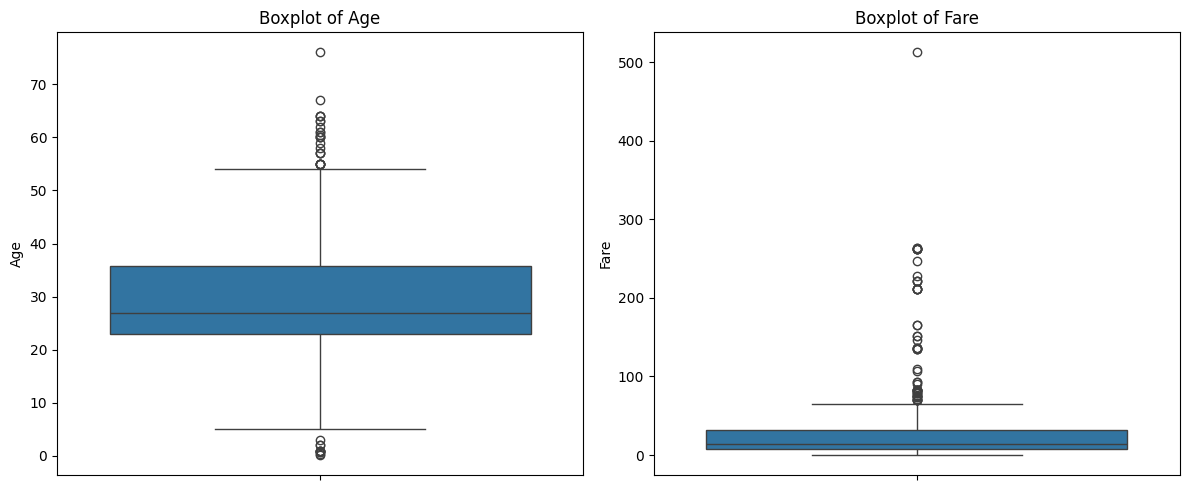

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=test1['Age'])
plt.title('Boxplot of Age')

plt.subplot(1, 2, 2)
sns.boxplot(y=test1['Fare'])
plt.title('Boxplot of Fare')

plt.tight_layout()
plt.show()

In [ ]:
# Function to replace outliers with IQR bounds
def replace_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers
    df.loc[df[column] < lower_bound, column] = lower_bound
    df.loc[df[column] > upper_bound, column] = upper_bound
    return df

# Apply to 'Age' column
test1 = replace_outliers_iqr(test1, 'Age')

# Apply to 'Fare' column
test1 = replace_outliers_iqr(test1, 'Fare')

print("Outliers in 'Age' and 'Fare' columns have been replaced.")

Outliers in 'Age' and 'Fare' columns have been replaced.


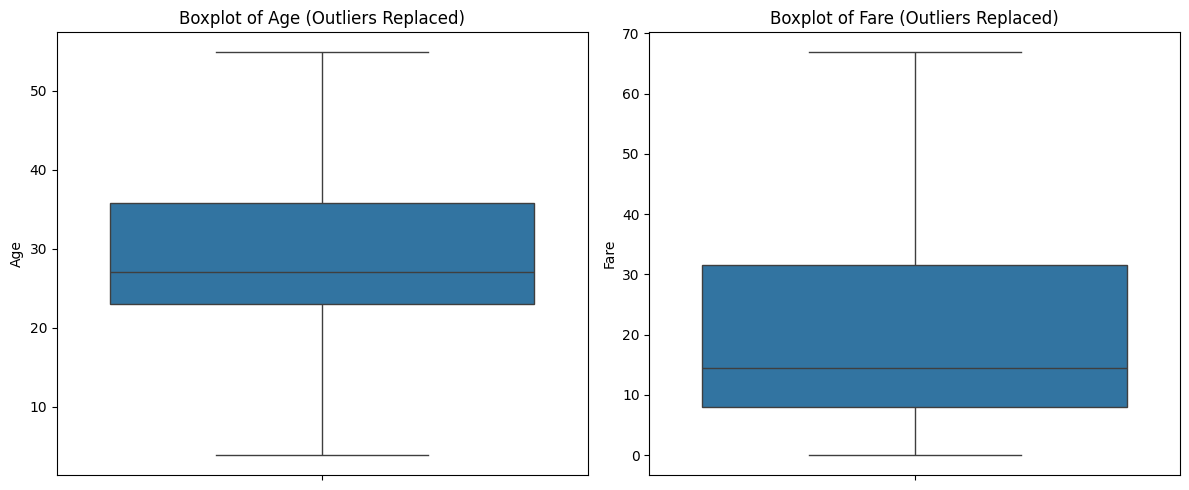

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=test1['Age'])
plt.title('Boxplot of Age (Outliers Replaced)')

plt.subplot(1, 2, 2)
sns.boxplot(y=test1['Fare'])
plt.title('Boxplot of Fare (Outliers Replaced)')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

test1[['Age', 'Fare']] = scaler.fit_transform(test1[['Age', 'Fare']])

print("Min-Max scaling applied to 'Age' and 'Fare' columns.")

Min-Max scaling applied to 'Age' and 'Fare' columns.


/tmp/ipykernel_8512/850907372.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1[['Age', 'Fare']] = scaler.fit_transform(test1[['Age', 'Fare']])


In [ ]:
test1

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,892,3,0,0.600490,0,0,0.117140,0,2
1,893,3,1,0.845588,1,0,0.104734,0,0
2,894,2,0,1.000000,0,0,0.144944,0,2
3,895,3,0,0.453431,0,0,0.129608,0,0
4,896,3,1,0.355392,1,1,0.183846,0,0
...,...,...,...,...,...,...,...,...,...
413,1305,3,0,0.453431,0,0,0.120444,0,0
414,1306,1,1,0.688725,0,0,1.000000,1,1
415,1307,3,0,0.678922,0,0,0.108474,0,0
416,1308,3,0,0.453431,0,0,0.120444,0,0


# **Modelling**

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [ ]:
from sklearn.model_selection import train_test_split

X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, y_pred_val)

0.8146067415730337

In [ ]:
# !pip install shap

In [ ]:
# import shap

# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_val)

In [ ]:
# shap.summary_plot(shap_values, X_val)

In [ ]:
model.fit(X, y)

X_test = test1.drop('PassengerId', axis=1)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
test1['Survived'] = y_pred

/tmp/ipykernel_8512/2577059637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Survived'] = y_pred


In [ ]:
test1

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,892,3,0,0.600490,0,0,0.117140,0,2,0
1,893,3,1,0.845588,1,0,0.104734,0,0,0
2,894,2,0,1.000000,0,0,0.144944,0,2,0
3,895,3,0,0.453431,0,0,0.129608,0,0,0
4,896,3,1,0.355392,1,1,0.183846,0,0,0
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,0.453431,0,0,0.120444,0,0,0
414,1306,1,1,0.688725,0,0,1.000000,1,1,1
415,1307,3,0,0.678922,0,0,0.108474,0,0,0
416,1308,3,0,0.453431,0,0,0.120444,0,0,0


In [ ]:
test1 = test1[['PassengerId','Survived']]

In [ ]:
test1.to_csv('submission_xgboost_1.csv', index=False)

# **Deep Learning Method**

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Rencana_Studi/Semester_VIII/Deep_Learning/UTS/kasus_satu/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Rencana_Studi/Semester_VIII/Deep_Learning/UTS/kasus_satu/test.csv')

In [ ]:
train = train[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Survived' ]]
test1 = test[['PassengerId','Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']]

In [ ]:
train['Cabin'] = train['Cabin'].fillna('U').apply(lambda x: x[0])
test1['Cabin'] = test1['Cabin'].fillna('U').apply(lambda x: x[0])

/tmp/ipykernel_8512/3393680247.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Cabin'] = test1['Cabin'].fillna('U').apply(lambda x: x[0])


In [ ]:
train.dropna(subset=['Embarked'], inplace=True)

In [ ]:
train['Age'].fillna(train['Age'].median(), inplace=True)
test1['Age'].fillna(test1['Age'].median(), inplace=True)

/tmp/ipykernel_8512/1502540115.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
/tmp/ipykernel_8512/1502540115.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
test1['Fare'].fillna(test1['Fare'].median(), inplace=True)

/tmp/ipykernel_8512/325940325.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test1['Fare'].fillna(test1['Fare'].median(), inplace=True)
/tmp/ipykernel_8512/325940325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Fare'].fillna(test1['Fare'].median(), inplace=True)


In [ ]:
# Function to replace outliers with IQR bounds
def replace_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers
    df.loc[df[column] < lower_bound, column] = lower_bound
    df.loc[df[column] > upper_bound, column] = upper_bound
    return df

# Apply to 'Age' column
train = replace_outliers_iqr(train, 'Age')

# Apply to 'Fare' column
train = replace_outliers_iqr(train, 'Fare')

print("Outliers in 'Age' and 'Fare' columns have been replaced.")

Outliers in 'Age' and 'Fare' columns have been replaced.


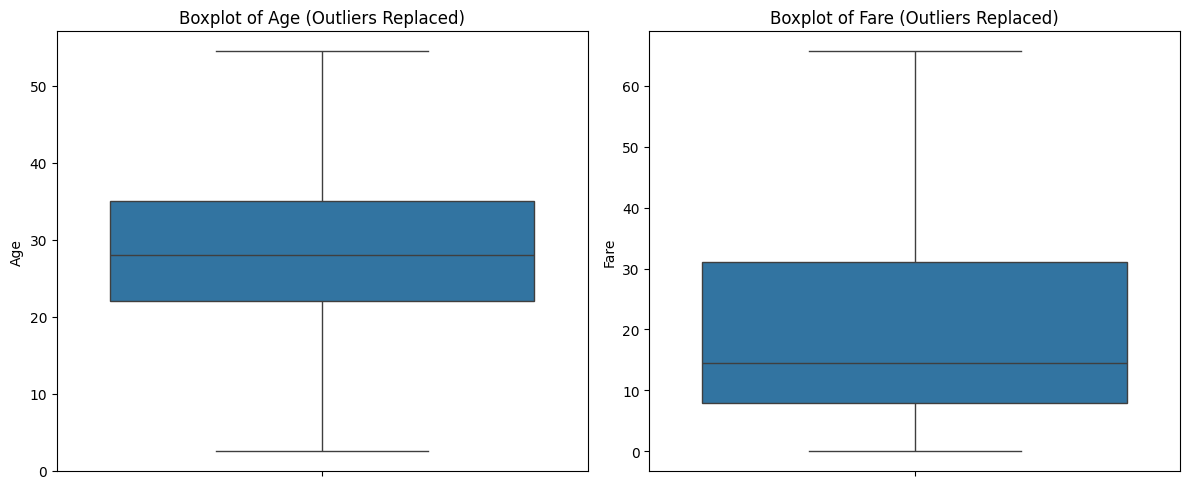

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=train['Age'])
plt.title('Boxplot of Age (Outliers Replaced)')

plt.subplot(1, 2, 2)
sns.boxplot(y=train['Fare'])
plt.title('Boxplot of Fare (Outliers Replaced)')

plt.tight_layout()
plt.show()

In [ ]:
# Function to replace outliers with IQR bounds
def replace_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers
    df.loc[df[column] < lower_bound, column] = lower_bound
    df.loc[df[column] > upper_bound, column] = upper_bound
    return df

# Apply to 'Age' column
train = replace_outliers_iqr(train, 'Age')

# Apply to 'Fare' column
train = replace_outliers_iqr(train, 'Fare')

print("Outliers in 'Age' and 'Fare' columns have been replaced.")

Outliers in 'Age' and 'Fare' columns have been replaced.


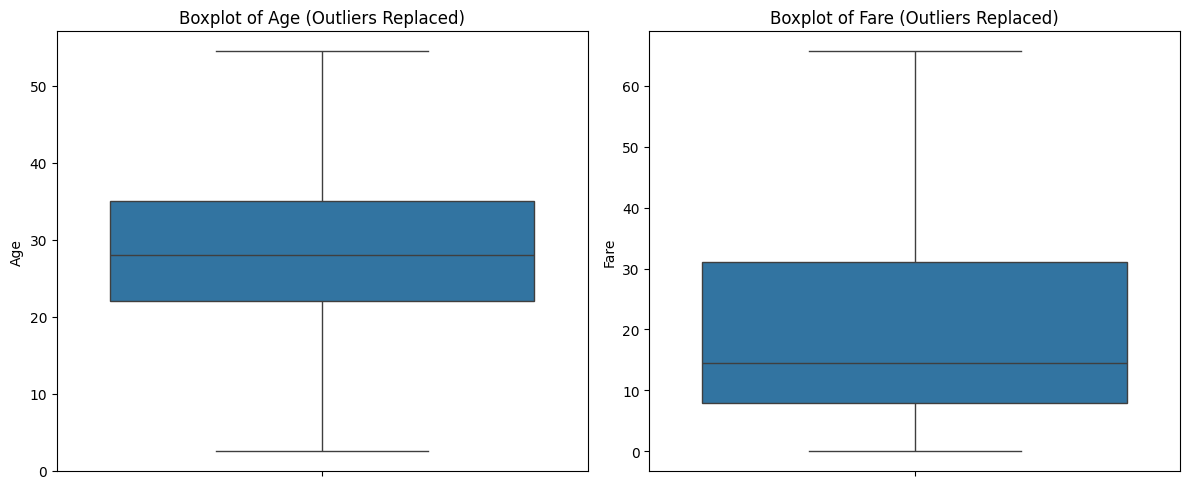

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=train['Age'])
plt.title('Boxplot of Age (Outliers Replaced)')

plt.subplot(1, 2, 2)
sns.boxplot(y=train['Fare'])
plt.title('Boxplot of Fare (Outliers Replaced)')

plt.tight_layout()
plt.show()

In [ ]:
sex_mapping = {'male': 0, 'female': 1}
train['Sex'] = train['Sex'].map(sex_mapping)

embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
train['Embarked'] = train['Embarked'].map(embarked_mapping)

cabin_mapping = {'U': 0, 'C': 1, 'B': 2, 'D':3, 'E':4, 'A':5, 'F':6, 'G':7, 'T':8}
train['Cabin'] = train['Cabin'].map(cabin_mapping)

In [ ]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,3,0,22.0,1,0,7.2500,0,0,0
1,1,1,38.0,1,0,65.6563,1,1,1
2,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,1
4,3,0,35.0,0,0,8.0500,0,0,0
...,...,...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,0,0,0
887,1,1,19.0,0,0,30.0000,2,0,1
888,3,1,28.0,1,2,23.4500,0,0,0
889,1,0,26.0,0,0,30.0000,1,1,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[['Age', 'Fare']] = scaler.fit_transform(train[['Age', 'Fare']])

print("Min-Max scaling applied to 'Age' and 'Fare' columns.")

Min-Max scaling applied to 'Age' and 'Fare' columns.


In [ ]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,3,0,0.375000,1,0,0.110424,0,0,0
1,1,1,0.682692,1,0,1.000000,1,1,1
2,3,1,0.451923,0,0,0.120704,0,0,1
3,1,1,0.625000,1,0,0.808757,1,0,1
4,3,0,0.625000,0,0,0.122608,0,0,0
...,...,...,...,...,...,...,...,...,...
886,2,0,0.471154,0,0,0.198001,0,0,0
887,1,1,0.317308,0,0,0.456925,2,0,1
888,3,1,0.490385,1,2,0.357163,0,0,0
889,1,0,0.451923,0,0,0.456925,1,1,1


In [ ]:
sex_mapping = {'male': 0, 'female': 1}
test1['Sex'] = test1['Sex'].map(sex_mapping)

embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
test1['Embarked'] = test1['Embarked'].map(embarked_mapping)

cabin_mapping = {'U': 0, 'C': 1, 'B': 2, 'D':3, 'E':4, 'A':5, 'F':6, 'G':7, 'T':8}
test1['Cabin'] = test1['Cabin'].map(cabin_mapping)

/tmp/ipykernel_8512/756365834.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Sex'] = test1['Sex'].map(sex_mapping)
/tmp/ipykernel_8512/756365834.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Embarked'] = test1['Embarked'].map(embarked_mapping)
/tmp/ipykernel_8512/756365834.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

test1[['Age', 'Fare']] = scaler.fit_transform(test1[['Age', 'Fare']])

print("Min-Max scaling applied to 'Age' and 'Fare' columns.")

Min-Max scaling applied to 'Age' and 'Fare' columns.


/tmp/ipykernel_8512/850907372.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1[['Age', 'Fare']] = scaler.fit_transform(test1[['Age', 'Fare']])


In [ ]:
test1

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,892,3,0,0.452723,0,0,0.015282,0,2
1,893,3,1,0.617566,1,0,0.013663,0,0
2,894,2,0,0.815377,0,0,0.018909,0,2
3,895,3,0,0.353818,0,0,0.016908,0,0
4,896,3,1,0.287881,1,1,0.023984,0,0
...,...,...,...,...,...,...,...,...,...
413,1305,3,0,0.353818,0,0,0.015713,0,0
414,1306,1,1,0.512066,0,0,0.212559,1,1
415,1307,3,0,0.505473,0,0,0.014151,0,0
416,1308,3,0,0.353818,0,0,0.015713,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6385 - loss: 0.6546 - val_accuracy: 0.7191 - val_loss: 0.6027
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7117 - loss: 0.5835 - val_accuracy: 0.7584 - val_loss: 0.5419
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7454 - loss: 0.5335 - val_accuracy: 0.7697 - val_loss: 0.5028
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7764 - loss: 0.4911 - val_accuracy: 0.7809 - val_loss: 0.4806
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7778 - loss: 0.4794 - val_accuracy: 0.7978 - val_loss: 0.4696
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4861 - val_accuracy: 0.8034 - val_loss: 0.4640
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7904 - loss: 0.4596 - val_accuracy: 0.8090 - val_loss: 0.4618
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7918 - loss: 0.4682 - val_accuracy: 0.8146 - v

In [ ]:
EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_val, y_pred_val)

array([[93, 16],
       [17, 52]])

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_val, y_pred_val)

0.8146067415730337

In [ ]:

X_test = test1.copy()
X_test = test1.drop('PassengerId', axis=1)
X_test = scaler.transform(X_test)

y_pred = (model.predict(X_test) > 0.5).astype(int)

test1['Survived'] = y_pred

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


/tmp/ipykernel_8512/3457784160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['Survived'] = y_pred


In [ ]:
test1

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,892,3,0,0.452723,0,0,0.015282,0,2,0
1,893,3,1,0.617566,1,0,0.013663,0,0,0
2,894,2,0,0.815377,0,0,0.018909,0,2,0
3,895,3,0,0.353818,0,0,0.016908,0,0,0
4,896,3,1,0.287881,1,1,0.023984,0,0,1
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,0.353818,0,0,0.015713,0,0,0
414,1306,1,1,0.512066,0,0,0.212559,1,1,1
415,1307,3,0,0.505473,0,0,0.014151,0,0,0
416,1308,3,0,0.353818,0,0,0.015713,0,0,0


In [ ]:
test1 = test1[['PassengerId', 'Survived']]

In [ ]:
test1.to_csv('submission_MLP.csv', index=False)